# 05_01_2 · Random Forest — Afinado con Optuna

**Objetivo:** el stacking del notebook 06 usa RF con parámetros por defecto.
Afinar el RF con Optuna puede mejorar su contribución al ensemble.

### Lógica de la mejora incremental
El proceso de construcción del modelo final sigue una estrategia iterativa:
1. Notebook 06: Stacking con componentes no optimizados → F1=0.879
2. **Este notebook**: Optimizar RF → ¿mejora el stacking?
3. Notebook 08: Añadir SVM al stacking → ¿añade diversidad útil?

En cada paso evaluamos si el cambio mejora el F1 con Recall ≥ 0.85.
Si no mejora, mantenemos el modelo anterior.

### ¿Por qué afinar RF específicamente?
LGBM ya fue afinado en el notebook 05. XGBoost tiene parámetros razonables con los defaults.
RF es el que más puede beneficiarse del tuning porque:
- `max_depth` puede estar limitando su capacidad
- `min_samples_leaf` puede estar sobreajustando (RF no tiene regularización implícita como boosting)

In [1]:
import sys; sys.path.insert(0, '../../src')
import pickle
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, f1_score,
    precision_score, recall_score
)
from utils import eval_threshold, LGBM_BEST_PARAMS   # compartidos en src/utils.py

with open('../../data/processed/splits.pkl', 'rb') as f:
    splits = pickle.load(f)
with open('../../models/models.pkl', 'rb') as f:
    models = pickle.load(f)

X_train, X_test, y_train, y_test = splits['ai4i']
print('Train:', X_train.shape, '| Fallos train:', y_train.sum())
print('Test: ', X_test.shape,  '| Fallos test: ', y_test.sum())


Train: (8000, 10) | Fallos train: 271
Test:  (2000, 10) | Fallos test:  68


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 1. Baseline RF (parámetros por defecto)


In [3]:
rf_base = models['rf']
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]
res_base = eval_threshold(y_test, y_prob_rf_base)
print('RF baseline:', res_base)


RF baseline: {'Precision': 0.6556, 'Recall': 0.8676, 'F1': 0.7468, 'ROC-AUC': 0.9797, 'Umbral': 0.15}


## 2. Optuna — afinar Random Forest

**Hiperparámetros a explorar y su impacto en el desbalanceo:**

| Parámetro | Qué controla | Relevancia para fallos |
|---|---|---|
| `n_estimators` | Número de árboles | Más árboles → más estabilidad pero diminishing returns |
| `max_depth` | Profundidad máxima de cada árbol | Sin límite, RF puede memorizar casos de fallo |
| `min_samples_split` / `min_samples_leaf` | Regularización de hojas | Evita splits con muy pocos fallos → hojas más robustas |
| `max_features` | Features consideradas en cada split | `sqrt` es el default; reducirlo aumenta diversidad de árboles |
| `class_weight` | `balanced` vs `balanced_subsample` | `balanced_subsample` recalcula los pesos en cada bootstrap |

**Métrica:** F1 sobre la clase fallo en CV 5-fold.
Usamos F1 aquí (en lugar de Recall como en el notebook 05) porque queremos
el mejor balance Precision-Recall, no solo Recall máximo.

In [4]:
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features',
                                                        ['sqrt', 'log2', 0.3, 0.5]),
        'class_weight':      trial.suggest_categorical('class_weight',
                                                        ['balanced', 'balanced_subsample']),
        'n_jobs': -1, 'random_state': 42,
    }
    scores = cross_val_score(RandomForestClassifier(**params),
                             X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print(f'\nMejor F1 CV RF: {study_rf.best_value:.4f}')
print('Mejores parámetros:')
for k, v in sorted(study_rf.best_params.items()):
    print(f'  {k}: {v}')


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor F1 CV RF: 0.8876
Mejores parámetros:
  class_weight: balanced_subsample
  max_depth: 16
  max_features: 0.5
  min_samples_leaf: 2
  min_samples_split: 6
  n_estimators: 314


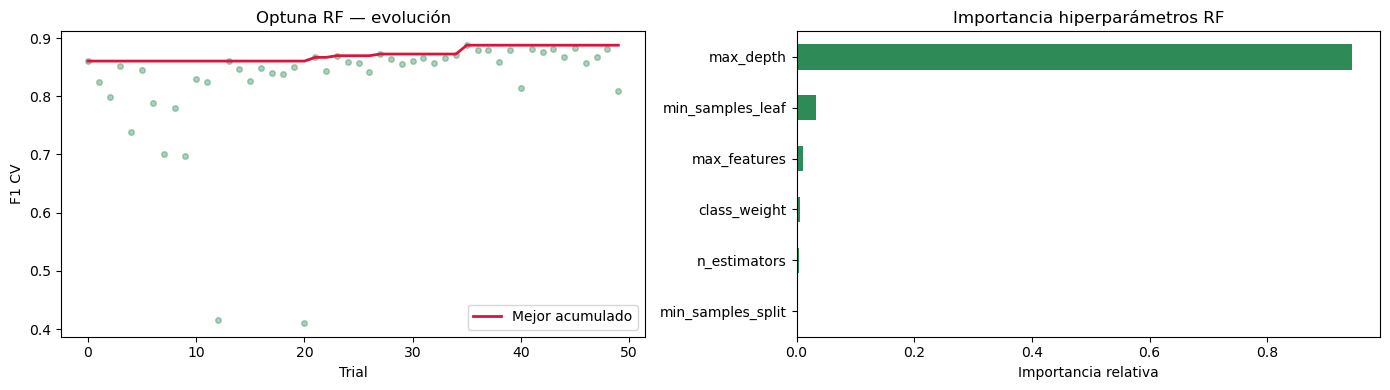

In [5]:
# Historial + importancia de hiperparámetros
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study_rf.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'],
             'o', alpha=0.4, color='seagreen', ms=4)
axes[0].plot(trials_df['number'], trials_df['value'].cummax(),
             color='crimson', lw=2, label='Mejor acumulado')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('F1 CV')
axes[0].set_title('Optuna RF — evolución')
axes[0].legend()

imp = optuna.importance.get_param_importances(study_rf)
pd.Series(imp).sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Importancia hiperparámetros RF')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()


## 3. RF afinado — evaluación en test


In [6]:
rf_tuned = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train, y_train)

y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]
res_rf_tuned = eval_threshold(y_test, y_prob_rf_tuned)
thr_rf = res_rf_tuned['Umbral']

print(f'=== RF afinado — umbral {thr_rf:.4f} ===')
print(classification_report(y_test, (y_prob_rf_tuned >= thr_rf).astype(int),
                             target_names=['Normal', 'Fallo']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.4f}')

print('\n--- RF baseline vs RF afinado ---')
print(pd.DataFrame({'RF baseline': res_base,
                     'RF afinado':  res_rf_tuned}).T.round(4).to_string())


=== RF afinado — umbral 0.3427 ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1932
       Fallo       0.86      0.84      0.85        68

    accuracy                           0.99      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9786

--- RF baseline vs RF afinado ---
             Precision  Recall      F1  ROC-AUC  Umbral
RF baseline     0.6556  0.8676  0.7468   0.9797  0.1500
RF afinado      0.8657  0.8529  0.8593   0.9786  0.3427


## 4. Guardar

Este notebook guarda **solo** `rf_tuned`. El ensemble se construye y selecciona en `05_01_4_Stacking_AI4I`.


In [7]:
import pickle as _pickle
_pkl = '../../models/models.pkl'
with open(_pkl, 'rb') as _f:
    _m = _pickle.load(_f)
_m['rf_tuned'] = rf_tuned
with open(_pkl, 'wb') as _f:
    _pickle.dump(_m, _f)
print('Guardado: rf_tuned | Total keys en pkl:', len(_m))


Guardado: rf_tuned | Total keys en pkl: 17


## 5. Conclusiones

- `rf_tuned` queda disponible en `models.pkl` para el ensemble.
- La construcción del stacking (v1/v2/v3), su comparativa y la elección del
  modelo de producción viven en **`05_01_4_Stacking_AI4I`**.
